In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
fraud_df = pd.read_csv('../data/creditcard.csv')

print(f"Dataset shape: {fraud_df.shape}")
print(f"Columns: {fraud_df.columns.tolist()}")

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [9]:
print(f"\nData Types: \n {fraud_df.dtypes}")



Data Types: 
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [13]:
print(f"\nTotal Missing Values:\n {fraud_df.isnull().sum().sum()}")


Total Missing Values:
 0


In [25]:
fraud_count = fraud_df['Class'].value_counts()
fraud_pct =fraud_df['Class'].value_counts(normalize=True)*100
print(f"Legitimate transactions:{fraud_count[0]:,} ({fraud_pct[0]:.3f}%)")
print(f"Fraudulent transactions: {fraud_count[1]:,} ({fraud_pct[1]:.3f}%)")
print(f"\nImbalance ratio: 1 fraud to every {int(fraud_count[0]/fraud_count[1])} legitimate transaction")

Legitimate transactions:284,315 (99.827%)
Fraudulent transactions: 492 (0.173%)

Imbalance ratio: 1 fraud to every 577 legitimate transaction


In [ ]:

fraud_pct

Class
0   99.83
1    0.17
Name: proportion, dtype: float64

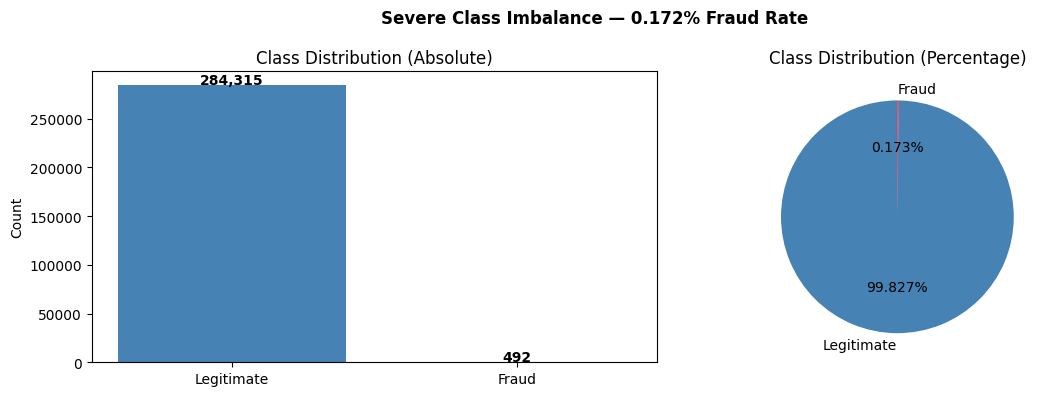

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
axes[0].bar(['Legitimate', 'Fraud'], fraud_count.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (Absolute)')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# pie chart
axes[1].pie(fraud_count.values, labels=['Legitimate', 'Fraud'], 
            colors=['steelblue', 'crimson'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.suptitle('Severe Class Imbalance — 0.172% Fraud Rate', fontweight='bold')
plt.tight_layout()
plt.show()

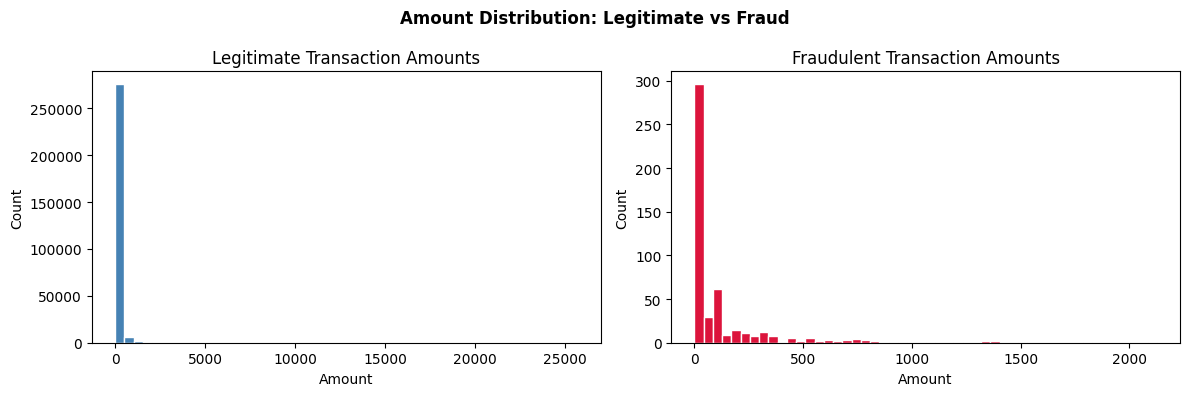

Amount Statistics by Class:
          count   mean    std  min  25%   50%    75%      max
Class                                                        
0     284315.00  88.29 250.11 0.00 5.65 22.00  77.05 25691.16
1        492.00 122.21 256.68 0.00 1.00  9.25 105.89  2125.87


In [ ]:
# amount distribution — fraudulent vs legitimate transactions


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# legitimate transactions
axes[0].hist(fraud_df[fraud_df['Class'] == 0]['Amount'], 
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
#fraudulent
axes[1].hist(fraud_df[fraud_df['Class'] == 1]['Amount'], 
             bins=50, color='crimson', edgecolor='white')
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')

plt.suptitle('Amount Distribution: Legitimate vs Fraud', fontweight='bold')
plt.tight_layout()
plt.show()

print("Amount Statistics by Class:")
print(fraud_df.groupby('Class')['Amount'].describe().round(2))

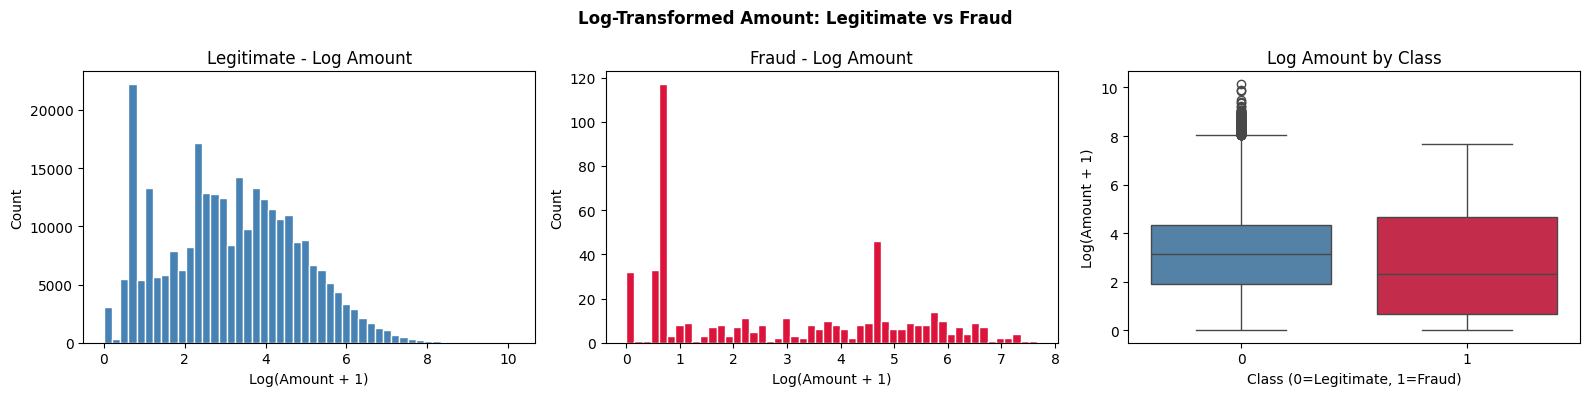

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# legitimate only
axes[0].hist(fraud_df[fraud_df['Class'] == 0]['Amount_log'],
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate - Log Amount')
axes[0].set_xlabel('Log(Amount + 1)')
axes[0].set_ylabel('Count')

# fraud only
axes[1].hist(fraud_df[fraud_df['Class'] == 1]['Amount_log'],
             bins=50, color='crimson', edgecolor='white')
axes[1].set_title('Fraud - Log Amount')
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].set_ylabel('Count')

# boxplot side by side
sns.boxplot(data=fraud_df, x='Class', y='Amount_log',
            palette={'0': 'steelblue', '1': 'crimson'}, ax=axes[2])
axes[2].set_title('Log Amount by Class')
axes[2].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[2].set_ylabel('Log(Amount + 1)')

plt.suptitle('Log-Transformed Amount: Legitimate vs Fraud', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Min Time: {fraud_df['Time'].min()}")
print(f"Max Time:{fraud_df['Time'].max()}")
print(f"Max Time in hours:{fraud_df['Time'].max()/3600:.1f}hours")


Min Time: 0.0
Max Time:172792.0
Max Time in hours:48.0hours


In [55]:
fraud_df['Hour'] =(fraud_df['Time']/3600 % 24).astype(int)


hourly = fraud_df.groupby('Hour')['Class'].agg(['sum', 'count'])
hourly.columns=['fraud_count', 'total_count']
hourly['fraud_rate'] = hourly['fraud_count']/hourly['total_count']*100

print(hourly)

      fraud_count  total_count  fraud_rate
Hour                                      
0               6         7695        0.08
1              10         4220        0.24
2              57         3328        1.71
3              17         3492        0.49
4              23         2209        1.04
5              11         2990        0.37
6               9         4101        0.22
7              23         7243        0.32
8               9        10276        0.09
9              16        15838        0.10
10              8        16598        0.05
11             53        16856        0.31
12             17        15420        0.11
13             17        15365        0.11
14             23        16570        0.14
15             26        16461        0.16
16             22        16453        0.13
17             29        16166        0.18
18             33        17039        0.19
19             19        15649        0.12
20             18        16756        0.11
21         

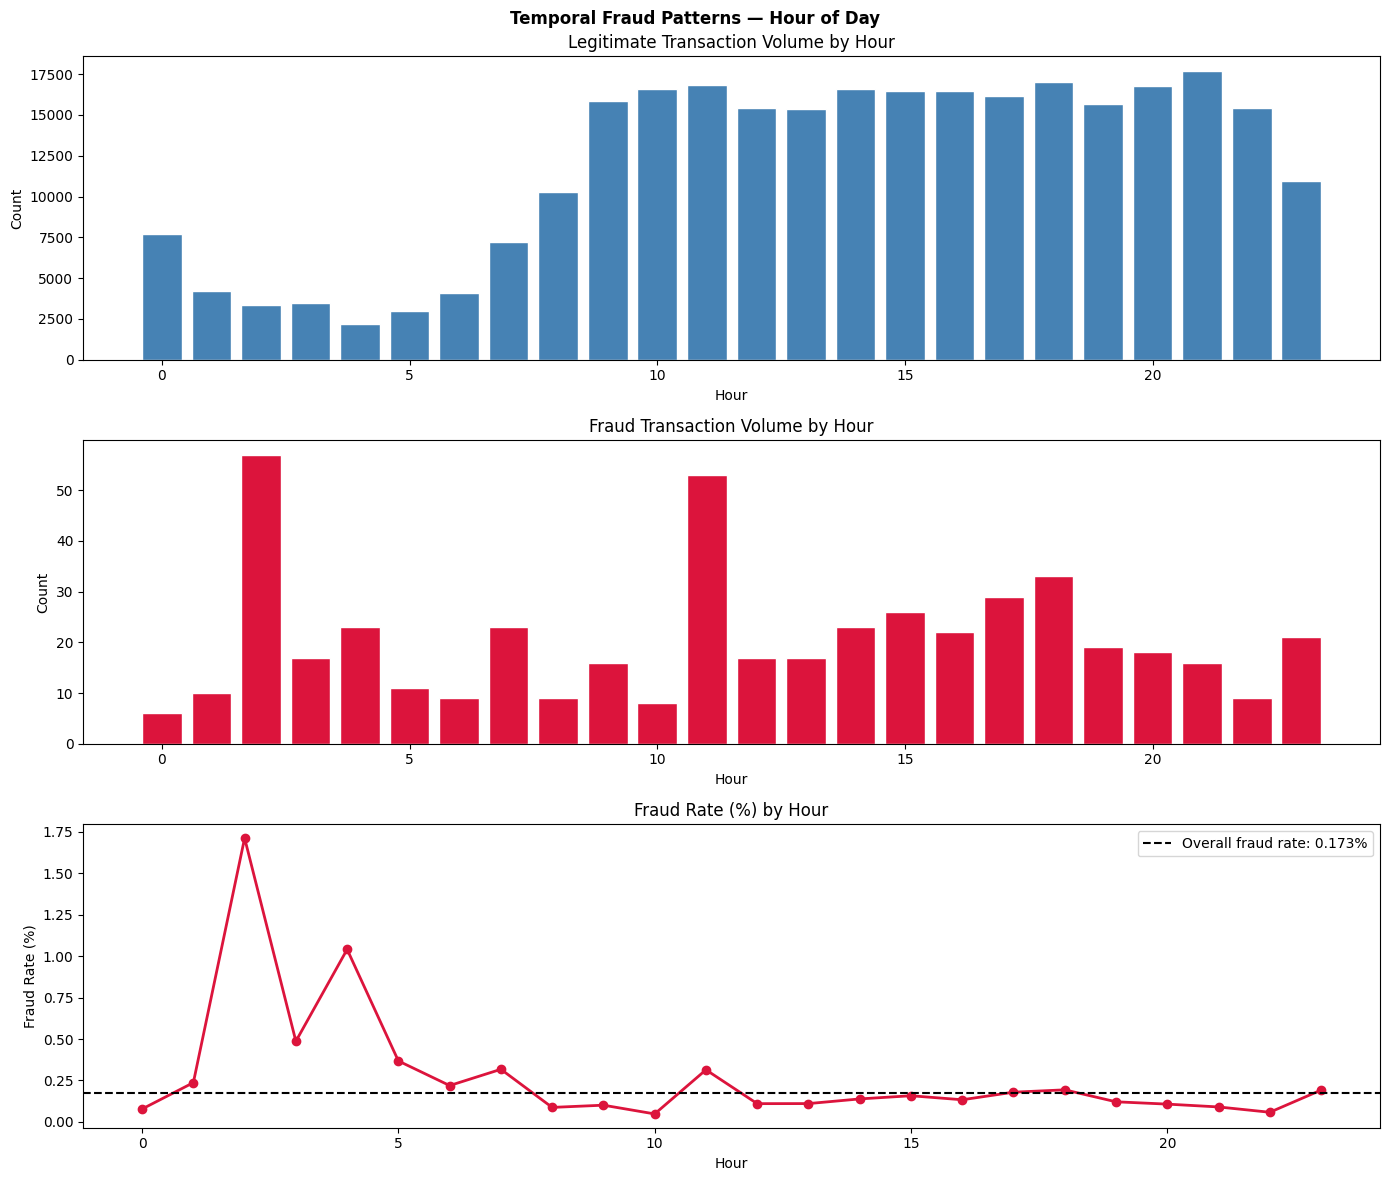

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# plot 1 — legitimate transaction volume by hour
axes[0].bar(hourly.index, hourly['total_count'], color='steelblue', edgecolor='white')
axes[0].set_title('Legitimate Transaction Volume by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# plot 2 — fraud transaction volume by hour
axes[1].bar(hourly.index, hourly['fraud_count'], color='crimson', edgecolor='white')
axes[1].set_title('Fraud Transaction Volume by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')

# plot 3 — fraud rate by hour with overall average line
axes[2].plot(hourly.index, hourly['fraud_rate'], color='crimson', 
             marker='o', linewidth=2)
axes[2].axhline(y=fraud_df['Class'].mean()*100, color='black',
                linestyle='--', 
                label=f'Overall fraud rate: {fraud_df["Class"].mean()*100:.3f}%')
axes[2].set_title('Fraud Rate (%) by Hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].legend()

plt.suptitle('Temporal Fraud Patterns — Hour of Day', fontweight='bold')
plt.tight_layout()
plt.show()

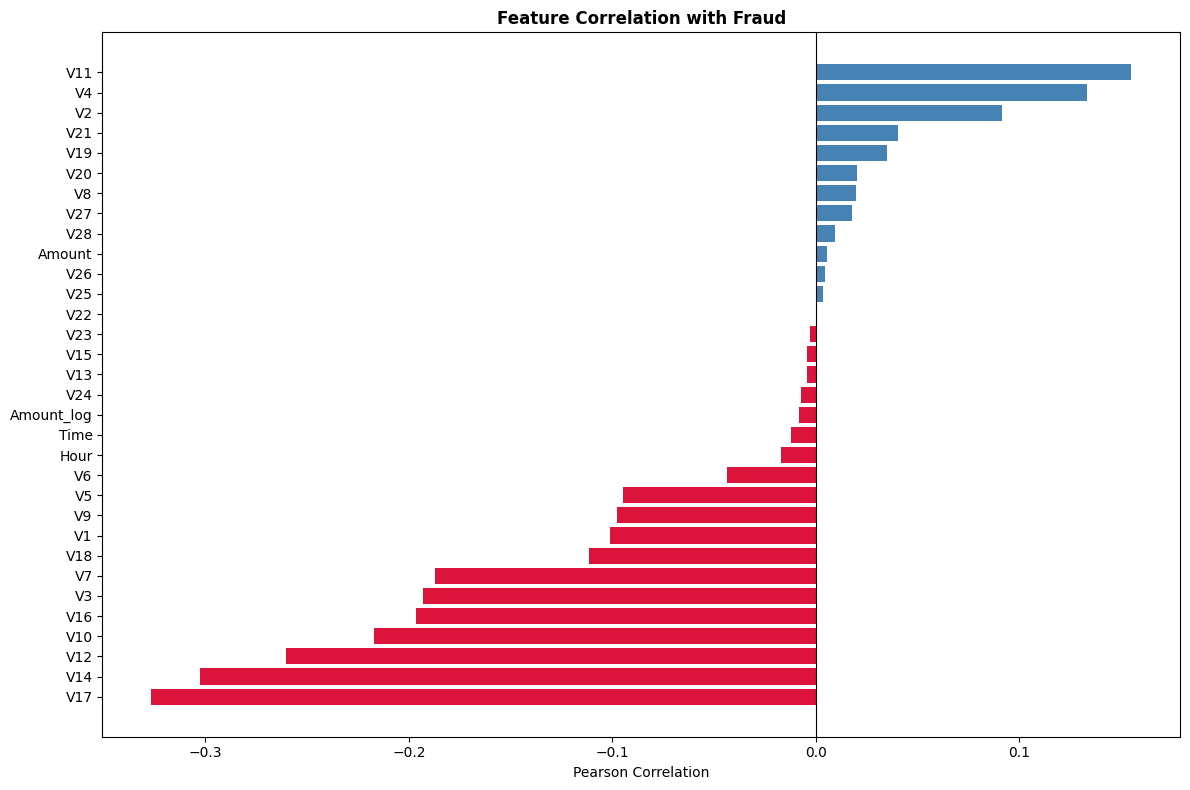

Top 5 positively correlated with fraud:
V19   0.04
V21   0.04
V2    0.09
V4    0.13
V11   0.15
Name: Class, dtype: float64

Top 5 negatively correlated with fraud:
V17   -0.33
V14   -0.30
V12   -0.26
V10   -0.22
V16   -0.20
Name: Class, dtype: float64


In [62]:
# correlation of each feature with Class (fraud) — bar chart is cleaner than heatmap
corr_with_fraud = fraud_df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(12, 8))
colors = ['crimson' if x < 0 else 'steelblue' for x in corr_with_fraud]
plt.barh(corr_with_fraud.index, corr_with_fraud.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Fraud', fontweight='bold')
plt.xlabel('Pearson Correlation')
# red = negative correlation, blue = positive correlation
plt.tight_layout()
plt.show()

print("Top 5 positively correlated with fraud:")
print(corr_with_fraud.tail(5).round(3))
print("\nTop 5 negatively correlated with fraud:")
print(corr_with_fraud.head(5).round(3))

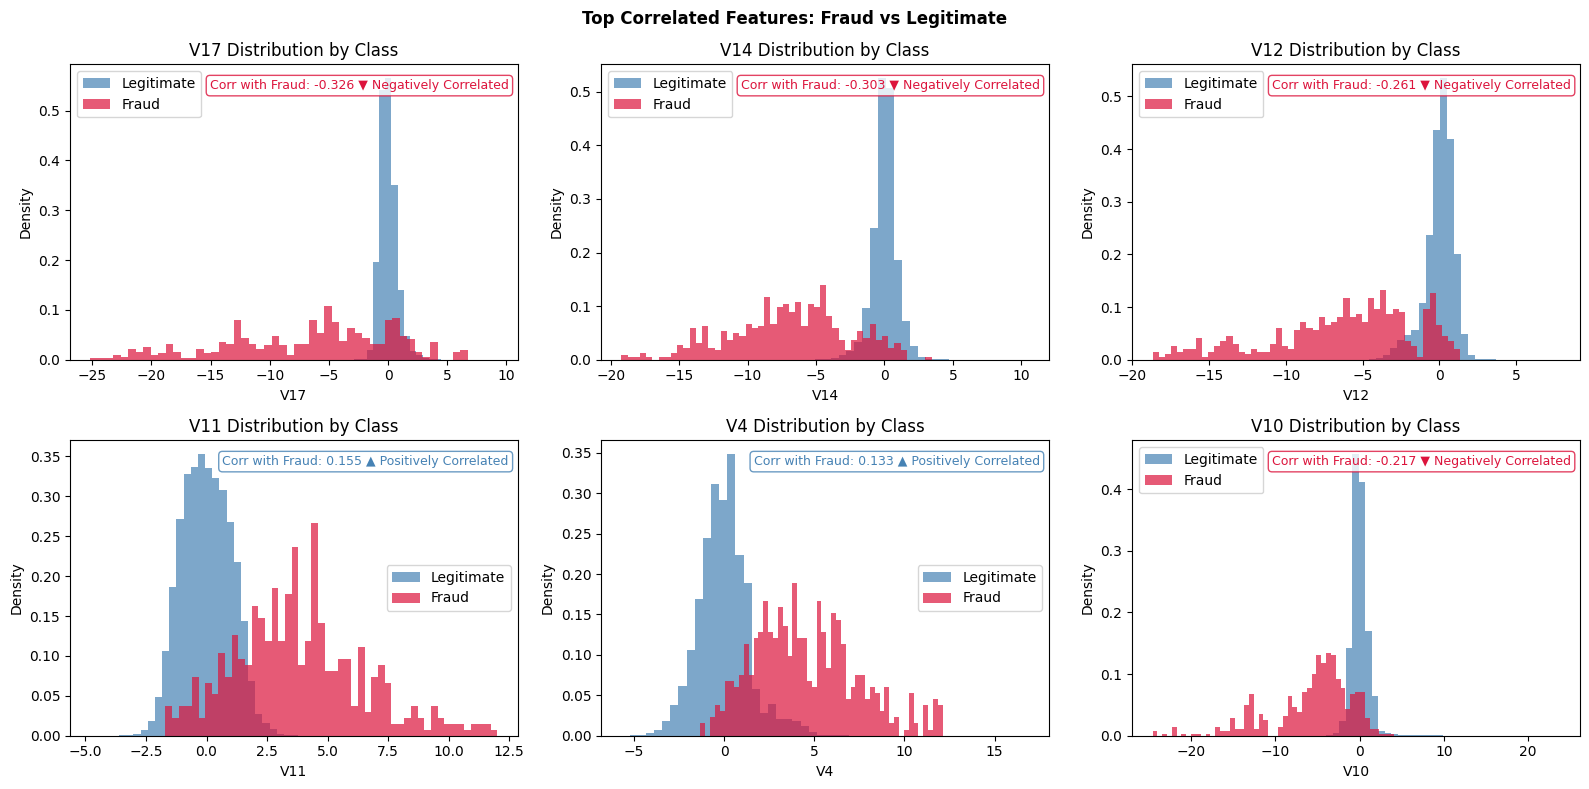

In [66]:
top_features = ['V17', 'V14', 'V12', 'V11', 'V4', 'V10']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].hist(fraud_df[fraud_df['Class'] == 0][feature], 
                 bins=50, color='steelblue', alpha=0.7, 
                 label='Legitimate', density=True)
    axes[i].hist(fraud_df[fraud_df['Class'] == 1][feature], 
                 bins=50, color='crimson', alpha=0.7, 
                 label='Fraud', density=True)
    
    # get correlation value for this feature
    corr_val = corr_with_fraud[feature]
    
    # label direction and colour based on correlation sign
    if corr_val < 0:
        corr_label = f'Corr with Fraud: {corr_val:.3f} ▼ Negatively Correlated'
        label_color = 'crimson'
    else:
        corr_label = f'Corr with Fraud: {corr_val:.3f} ▲ Positively Correlated'
        label_color = 'steelblue'
    
    axes[i].set_title(f'{feature} Distribution by Class')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    
    # add correlation label inside the chart
    axes[i].text(0.98, 0.95, corr_label,
                 transform=axes[i].transAxes,
                 fontsize=9, color=label_color,
                 ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='white', 
                           edgecolor=label_color, 
                           alpha=0.8))

plt.suptitle('Top Correlated Features: Fraud vs Legitimate', fontweight='bold')
plt.tight_layout()
plt.show()

In [67]:
# are outliers fraud or legitimate?
# check extreme values of Amount by class
print("Legitimate - Amount outliers (top 10):")
print(fraud_df[fraud_df['Class']==0]['Amount'].nlargest(10))

print("\nFraud - Amount outliers (top 10):")
print(fraud_df[fraud_df['Class']==1]['Amount'].nlargest(10))

Legitimate - Amount outliers (top 10):
274771   25691.16
58465    19656.53
151296   18910.00
46841    12910.93
54018    11898.09
169457   11789.84
284249   10199.44
227921   10000.00
74699     8790.26
245474    8787.00
Name: Amount, dtype: float64

Fraud - Amount outliers (top 10):
176049   2125.87
6971     1809.68
249167   1504.93
89190    1402.16
81609    1389.56
95597    1354.25
199896   1335.00
10690    1218.89
249239   1096.99
233258    996.27
Name: Amount, dtype: float64
